# Latent Belief Inference via Gaussian Expressive Noise



Goal: infer a **latent belief trajectory** $z_i(t)$ for each agent $i$ at each self-expression step $t$.



We treat an agent’s **published stance** as a noisy expression of latent belief:

$$x_i(t) = z_i(t) + \mu_\eta(\phi_i(t)) + \varepsilon_i(t),\qquad \varepsilon_i(t)\sim\mathcal N(0,\sigma_\eta(\phi_i(t))^2).$$



- $x_i(t)$ comes from per-agent logs as `published.stance_score` **at self-expression events** (`is_self_influence == True`).

- $z_i(t)$ is latent (unobserved). We also have a **proxy latent** diagnostic `topology_profile_for_agent.ss` which we call `obs_z`.

- $\phi_i(t)$ are extra predictors for expressive bias/variance (topic similarity, strength, topology stats, anchor similarities, etc.).



We model belief dynamics with a DeGroot-style prior (no access to current $x_i(t)$):

$$z_i(t) = \alpha_i\,z_i(t-1) + (1-\alpha_i)\,\text{social}_i(t) + w_i(t),\qquad w_i(t)\sim\mathcal N(0,q_i^2).$$



Then we do a scalar Kalman-style update using the observation model above to produce $\hat z_i(t)$.



**Bias/variance / overfitting control:**

- We evaluate candidate expressive-noise feature sets with **leave-one-run-out** (hold out whole runs).

- We tune $(\alpha_i,q_i)$ using **run-level CV** on innovation likelihood (so variance is calibrated for new runs).

- Finally, we refit the chosen models on **all available data** for deployment to new runs.


In [1]:
import json
import math
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print


In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / 'modeling' / 'cleaned_data').exists():
            return p
    return start

CWD = Path.cwd()
ROOT = find_repo_root(CWD)
CLEAN = ROOT / 'modeling' / 'cleaned_data'
RUN_DIRS = sorted([p for p in CLEAN.glob('run_*') if p.is_dir()])
assert RUN_DIRS, f'No run_* folders in {CLEAN}'

PARAMS = {
    'alpha_grid': [round(x, 2) for x in np.linspace(0.0, 1.0, 21)],
    'min_samples_per_agent': 25,
}

print('CWD:', CWD)
print('ROOT:', ROOT)
print('Runs:', [p.name for p in RUN_DIRS])
print('alpha_grid size:', len(PARAMS['alpha_grid']))


CWD: /home/sammli/llm-network/modeling/models/latent_belief
ROOT: /home/sammli/llm-network
Runs: ['run_20260216-211459', 'run_20260216-225353', 'run_20260217-000531', 'run_20260217-150345', 'run_20260217-185316', 'run_20260217-223650']
alpha_grid size: 21


In [3]:
def load_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def load_jsonl(path: Path):
    rows = []
    if not path.exists():
        return rows
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def numeric_agent_key(agent_id: str):
    if isinstance(agent_id, str) and agent_id.startswith('agent_'):
        tail = agent_id.split('_')[-1]
        if tail.isdigit():
            return int(tail)
    return 10**9


def parse_agent_id(v):
    if isinstance(v, str) and v.startswith('agent_'):
        return v
    if isinstance(v, int):
        return f'agent_{v}'
    return None


def to_int_list(values):
    out = []
    if not isinstance(values, list):
        return out
    for x in values:
        try:
            out.append(int(x))
        except Exception:
            continue
    return out


def get_graph_adjacency(graph):
    # Supports either {'edges': [[src, dst], ...]} or {src: [dst,...]}.
    if isinstance(graph, dict) and 'edges' in graph:
        adj = defaultdict(list)
        for src, dst in graph.get('edges', []):
            s = parse_agent_id(src)
            d = parse_agent_id(dst)
            if s and d:
                adj[s].append(d)
        return dict(adj)
    if isinstance(graph, dict):
        return {k: list(v) for k, v in graph.items() if isinstance(v, list)}
    return {}


def build_predecessors(graph_adj, agent_ids):
    preds = {a: [] for a in agent_ids}
    for src, dsts in graph_adj.items():
        for dst in dsts:
            if dst in preds:
                preds[dst].append(src)
    return preds


## 1) Load + align data (self-expression events)



Important alignment detail: `messages_with_alignment.jsonl` is indexed by **messages** (one sender per index), while `per_agent/agent_*.jsonl` is indexed by **snapshots** per agent per message index.



For *expressive noise per agent*, we only keep rows where the agent is the sender / expressing (`is_self_influence == True`).


In [4]:
def build_sender_lookup(run_dir: Path) -> dict[int, str | None]:
    sender_by_index: dict[int, str | None] = {}
    for m in load_jsonl(run_dir / 'messages_with_alignment.jsonl'):
        idx = m.get('index')
        if idx is None:
            continue
        try:
            k = int(idx)
        except Exception:
            continue
        sender_by_index[k] = parse_agent_id(m.get('sender_id'))
    return sender_by_index


def iter_agent_rows_sorted(per_agent_fp: Path):
    rows = load_jsonl(per_agent_fp)

    def key(r):
        try:
            return int(r.get('message_index', 10**18))
        except Exception:
            return 10**18

    return sorted(rows, key=key)


def compute_event_features(run_dir: Path) -> pd.DataFrame:
    """Build one row per *expressive event* (agent i publishes a message).

    We detect express events via `is_self_influence == True` in per-agent logs.

    Outputs include additional predictors of expressive noise beyond (x, z):
    - Published: topic_similarity, strength, anchor-group similarities
    - Topology profile: ts, str
    - Exposure: used indices counts and predecessor-filtered counts

    Note: We compute `social` using predecessor messages' *proxy latent* (their self z at those message indices).
    This makes the dataset construction deterministic and decoupled from any latent-belief estimator.
    """

    manifest = load_json(run_dir / 'run_manifest.json') if (run_dir / 'run_manifest.json').exists() else {}
    static_init = load_json(run_dir / 'static_init.json') if (run_dir / 'static_init.json').exists() else {}
    stance_weights = (static_init.get('stance_weights') or {})
    topic = manifest.get('topic') or static_init.get('topic') or ''

    graph_adj = get_graph_adjacency(load_json(run_dir / 'connection_graph.json'))
    sender_by_index = build_sender_lookup(run_dir)

    per_agent_dir = run_dir / 'per_agent'
    agent_ids = sorted([p.stem for p in per_agent_dir.glob('agent_*.jsonl')], key=numeric_agent_key)
    preds = build_predecessors(graph_adj, agent_ids)

    # Pass 1: collect each agent's self-message proxy latent by message index.
    # This lets us compute social influence using *the sender's own* proxy latent at that time.
    self_z_by_index: dict[int, float] = {}

    # Keep candidate events to fill social in Pass 2.
    candidate_events: list[dict] = []

    for fp in sorted(per_agent_dir.glob('agent_*.jsonl')):
        agent = fp.stem
        last_seen_z: float | None = None

        for row in iter_agent_rows_sorted(fp):
            t = row.get('message_index')
            if t is None:
                continue
            try:
                t = int(t)
            except Exception:
                continue

            topo = row.get('topology_profile_for_agent', {}) or {}
            ss = topo.get('ss', None)
            obs_z = float(ss) if ss is not None else np.nan

            z_prev = float(last_seen_z) if last_seen_z is not None else obs_z

            is_self = bool(row.get('is_self_influence'))
            if is_self and np.isfinite(obs_z):
                self_z_by_index[t] = obs_z

            if is_self:
                pub = row.get('published', {}) or {}

                stance = pub.get('stance_score', None)
                obs_x = float(stance) if stance is not None else np.nan

                topic_sim = pub.get('topic_similarity', None)
                pub_topic_similarity = float(topic_sim) if topic_sim is not None else np.nan

                strength = pub.get('strength', None)
                pub_strength = float(strength) if strength is not None else np.nan

                ags = pub.get('anchor_group_similarities', {}) or {}
                anchor_pro = ags.get('pro', None)
                anchor_anti = ags.get('anti', None)
                anchor_neutral = ags.get('neutral', None)

                topo_ts = topo.get('ts', None)
                topo_str = topo.get('str', None)

                used = to_int_list(row.get('used_indices'))
                if not used:
                    used = to_int_list(row.get('recommendation_indices'))

                candidate_events.append(
                    {
                        't': t,
                        'agent': agent,
                        'obs_x': obs_x,
                        'obs_z': obs_z,
                        'z_prev': z_prev,
                        'used_indices': used,
                        'pub_topic_similarity': pub_topic_similarity,
                        'pub_strength': pub_strength,
                        'anchor_pro': float(anchor_pro) if anchor_pro is not None else np.nan,
                        'anchor_anti': float(anchor_anti) if anchor_anti is not None else np.nan,
                        'anchor_neutral': float(anchor_neutral) if anchor_neutral is not None else np.nan,
                        'topo_ts': float(topo_ts) if topo_ts is not None else np.nan,
                        'topo_str': float(topo_str) if topo_str is not None else np.nan,
                    }
                )

            if np.isfinite(obs_z):
                last_seen_z = obs_z

    # Pass 2: compute social from used indices (predecessor-filtered).
    rows = []
    for ev in candidate_events:
        agent = ev['agent']
        used = ev['used_indices']

        z_used = []
        used_pred_senders: list[str] = []

        for idx in used:
            sender = sender_by_index.get(int(idx))
            if sender is None:
                continue
            if sender not in preds.get(agent, []):
                continue
            z_sender = self_z_by_index.get(int(idx))
            if z_sender is None or not np.isfinite(z_sender):
                continue
            used_pred_senders.append(sender)
            z_used.append(float(z_sender))

        social = float(np.mean(z_used)) if z_used else float(ev['z_prev'])

        rows.append(
            {
                'run': run_dir.name.replace('run_', ''),
                'topic': topic,
                't': int(ev['t']),
                'agent': agent,
                'stance_weight': float(stance_weights.get(agent)) if agent in stance_weights else np.nan,
                'obs_z': float(ev['obs_z']),
                'obs_x': float(ev['obs_x']),
                'z_prev': float(ev['z_prev']),
                'social': social,
                'n_used_total': int(len(used)),
                'n_used_pred': int(len(z_used)),
                'used_pred_senders': used_pred_senders,
                'pub_topic_similarity': float(ev['pub_topic_similarity']),
                'pub_strength': float(ev['pub_strength']),
                'anchor_pro': float(ev['anchor_pro']),
                'anchor_anti': float(ev['anchor_anti']),
                'anchor_neutral': float(ev['anchor_neutral']),
                'topo_ts': float(ev['topo_ts']),
                'topo_str': float(ev['topo_str']),
            }
        )

    df = pd.DataFrame(rows)
    df = df.sort_values(['t', 'agent']).reset_index(drop=True)

    # Proxy expressive noise relative to profile proxy latent.
    df['eta_profile'] = df['obs_x'] - df['obs_z']

    return df


In [5]:
def jarque_bera_stats(x: np.ndarray) -> dict:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = int(x.size)
    if n < 8:
        return {
            'n': n,
            'mean': np.nan,
            'std': np.nan,
            'skew': np.nan,
            'kurt': np.nan,
            'jb': np.nan,
            'p': np.nan,
        }

    mu = float(np.mean(x))
    v = float(np.mean((x - mu) ** 2))
    if v <= 0:
        return {
            'n': n,
            'mean': mu,
            'std': 0.0,
            'skew': 0.0,
            'kurt': 3.0,
            'jb': 0.0,
            'p': 1.0,
        }

    std = math.sqrt(v)
    m3 = float(np.mean((x - mu) ** 3))
    m4 = float(np.mean((x - mu) ** 4))

    skew = m3 / (v ** 1.5)
    kurt = m4 / (v ** 2)

    # JB ~ Chi^2(df=2) under Normality; survival for df=2 is exp(-JB/2)
    jb = (n / 6.0) * (skew**2 + ((kurt - 3.0) ** 2) / 4.0)
    p = math.exp(-0.5 * jb)

    return {
        'n': n,
        'mean': mu,
        'std': std,
        'skew': float(skew),
        'kurt': float(kurt),
        'jb': float(jb),
        'p': float(p),
    }


def _design_matrix(df: pd.DataFrame, feature_cols: list[str]) -> np.ndarray:
    """Builds a simple (intercept + columns) design matrix.

    Missing / non-finite values are zero-filled. This is deliberate: these features are
    mostly bounded similarity/strength stats, and we prefer a stable default over dropping rows.
    """
    X_cols = [np.ones((len(df), 1), dtype=float)]
    for c in feature_cols:
        v = df[c].to_numpy(dtype=float)
        v = np.where(np.isfinite(v), v, 0.0)
        X_cols.append(v.reshape(-1, 1))
    return np.hstack(X_cols)


def _ridge_fit(X: np.ndarray, y: np.ndarray, l2: float = 1e-6) -> np.ndarray:
    """Ridge least squares: beta = argmin ||Xb - y||^2 + l2||b||^2.

    If l2 == 0, falls back to least squares (handles rank-deficiency).
    """
    l2 = float(l2)
    if not np.isfinite(l2) or l2 < 0:
        raise ValueError(f"l2 must be finite and >= 0, got {l2}")
    if l2 == 0.0:
        # Robust to singular X^T X (rank-deficient designs).
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        return beta
    XtX = X.T @ X
    reg = l2 * np.eye(XtX.shape[0])
    return np.linalg.solve(XtX + reg, X.T @ y)


def fit_noise_model(
    df: pd.DataFrame,
    y_col: str,
    feature_cols: list[str],
    l2: float = 1e-6,
    eps_log: float = 1e-6,
 ):
    """Fits a heteroscedastic Gaussian model for expressive noise.

    We assume:
      y = mu(phi) + eps,    eps ~ N(0, sigma(phi)^2)
    where:
    - mu(phi) is linear in features
    - log sigma(phi)^2 is linear in the same features

    Practical fitting approach (fast + stable):
    1) Fit mu via ridge least squares
    2) Fit log-variance via ridge least squares on log(resid^2 + eps)
    3) Calibrate a scalar `sigma_scale` so standardized residuals have unit RMS on training

    NOTE: We use ridge mostly for numerical stability / mild regularization.
    We can choose `l2` via leave-one-run-out validation on held-out runs.
    """
    d = df.copy()
    y = d[y_col].to_numpy(dtype=float)
    mask = np.isfinite(y)
    d = d.loc[mask].copy()
    y = y[mask]

    # Mean model: mu_hat = X beta_mu
    X = _design_matrix(d, feature_cols)
    beta_mu = _ridge_fit(X, y, l2=l2)
    mu_hat = X @ beta_mu

    resid = y - mu_hat
    target = np.log(resid * resid + float(eps_log))

    # Variance model: log sigma^2 = X beta_logv
    beta_logv = _ridge_fit(X, target, l2=l2)
    logv_hat = X @ beta_logv
    sigma_hat = np.exp(0.5 * logv_hat)
    sigma_hat = np.maximum(sigma_hat, 1e-4)

    # Calibrate sigma scale on training so E[(resid/sigma)^2] ~ 1
    z = resid / sigma_hat
    z = z[np.isfinite(z)]
    sigma_scale = float(np.sqrt(np.mean(z * z))) if z.size else 1.0
    if not np.isfinite(sigma_scale) or sigma_scale <= 0:
        sigma_scale = 1.0

    return {
        'feature_cols': list(feature_cols),
        'beta_mu': beta_mu,
        'beta_logv': beta_logv,
        'sigma_scale': sigma_scale,
        'l2': float(l2),
        'eps_log': float(eps_log),
    }


def predict_noise(model, df: pd.DataFrame):
    """Predicts (mu, sigma) for a batch of rows."""
    X = _design_matrix(df, model['feature_cols'])
    mu = X @ model['beta_mu']
    logv = X @ model['beta_logv']
    sigma = np.exp(0.5 * logv)
    sigma = np.maximum(sigma, 1e-4)
    sigma = sigma * float(model.get('sigma_scale', 1.0))
    return mu, sigma


def standardized_residuals(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=float)
    mu = np.asarray(mu, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    m = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(m):
        return np.asarray([], dtype=float)
    return (y[m] - mu[m]) / sigma[m]


def gaussian_nll(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
    """Mean Gaussian NLL for y ~ N(mu, sigma^2)."""
    y = np.asarray(y, dtype=float)
    mu = np.asarray(mu, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    m = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(m):
        return float('nan')
    yy = y[m]
    mm = mu[m]
    ss = sigma[m]
    return float(0.5 * np.mean(np.log(2 * np.pi * ss * ss) + ((yy - mm) ** 2) / (ss * ss)))


def cv_pick_l2_noise_model(
    df: pd.DataFrame,
    *,
    y_col: str,
    feature_cols: list[str],
    run_col: str = 'run',
    l2_grid: np.ndarray | list[float] | None = None,
    min_train: int = 200,
    min_val: int = 50,
 ) -> tuple[float, pd.DataFrame]:
    """Leave-one-run-out CV for ridge l2 using Gaussian NLL on held-out runs.

    Returns: (best_l2, scores_df)
    - scores_df has one row per (l2, holdout_run) fold, plus an aggregate summary per l2.
    """
    if l2_grid is None:
        l2_grid = np.array([0.0, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2], dtype=float)
    l2_grid = np.asarray(l2_grid, dtype=float)
    l2_grid = l2_grid[np.isfinite(l2_grid) & (l2_grid >= 0)]
    if l2_grid.size == 0:
        raise ValueError('l2_grid must contain at least one finite >=0 value')
    if run_col not in df.columns:
        raise KeyError(f"cv_pick_l2_noise_model expected column '{run_col}'")

    d0 = df.copy()
    y0 = d0[y_col].to_numpy(dtype=float)
    d0 = d0.loc[np.isfinite(y0)].copy()
    if len(d0) < (min_train + min_val):
        # Too little data; fall back to the default that keeps the pipeline stable.
        return float(l2_grid[np.argmin(np.abs(l2_grid - 1e-6))]), pd.DataFrame()

    runs = [r for r in pd.unique(d0[run_col]) if r is not None]
    runs = sorted(runs, key=lambda x: str(x))
    if len(runs) < 2:
        return float(l2_grid[np.argmin(np.abs(l2_grid - 1e-6))]), pd.DataFrame()

    rows: list[dict] = []
    for holdout in runs:
        dtr = d0[d0[run_col] != holdout].copy()
        dve = d0[d0[run_col] == holdout].copy()
        if len(dtr) < min_train or len(dve) < min_val:
            continue
        y_val = dve[y_col].to_numpy(dtype=float)
        for l2 in l2_grid:
            model = fit_noise_model(dtr, y_col=y_col, feature_cols=feature_cols, l2=float(l2))
            mu, sigma = predict_noise(model, dve[feature_cols])
            nll = gaussian_nll(y_val, mu, sigma)
            rows.append({
                'holdout': str(holdout),
                'l2': float(l2),
                'n_val': int(np.isfinite(y_val).sum()),
                'nll': float(nll) if np.isfinite(nll) else np.nan,
            })

    scores = pd.DataFrame(rows)
    if scores.empty:
        return float(l2_grid[np.argmin(np.abs(l2_grid - 1e-6))]), scores

    # Aggregate per l2: weighted by n_val
    agg = (
        scores.dropna(subset=['nll'])
        .groupby('l2')
        .apply(lambda g: pd.Series({
            'folds': int(g.shape[0]),
            'n_val_total': int(g['n_val'].sum()),
            'nll_wavg': float(np.average(g['nll'], weights=np.maximum(1, g['n_val']))),
            'nll_mean': float(g['nll'].mean()),
        }))
        .reset_index()
        .sort_values(['nll_wavg', 'nll_mean', 'l2'], ascending=[True, True, True])
    )
    best_l2 = float(agg.iloc[0]['l2']) if not agg.empty else float(l2_grid[0])

    # Put agg at the bottom for display convenience
    scores = scores.sort_values(['l2', 'holdout']).reset_index(drop=True)
    fold = scores.assign(_kind='fold')
    agg2 = agg.assign(holdout='__AGG__', n_val=agg['n_val_total'], nll=agg['nll_wavg'], _kind='agg')
    out = pd.concat([fold, agg2[['holdout', 'l2', 'n_val', 'nll', '_kind']]], ignore_index=True)
    return best_l2, out


# Existing DeGroot-only predictor utilities (kept for comparison)

def add_pred_columns(df: pd.DataFrame, alpha_grid) -> pd.DataFrame:
    out = df.copy()
    for a in alpha_grid:
        a = float(a)
        out[f'pred_z_a{a}'] = a * out['z_prev'] + (1.0 - a) * out['social']
        out[f'eta_a{a}'] = out['obs_x'] - out[f'pred_z_a{a}']
    if 'eta_profile' not in out.columns:
        out['eta_profile'] = out['obs_x'] - out['obs_z']
    return out


def best_alpha_for_group(df_group: pd.DataFrame, alpha_grid):
    best = None
    for a in alpha_grid:
        a = float(a)
        st = jarque_bera_stats(df_group[f'eta_a{a}'].to_numpy())
        if best is None or (np.isfinite(st['p']) and st['p'] > best['p']):
            best = {'alpha': a, **st}
    return best


def rmse_vs_obs_z(df_group: pd.DataFrame, pred_col: str) -> float:
    d = (df_group[pred_col] - df_group['obs_z']).to_numpy(dtype=float)
    d = d[np.isfinite(d)]
    if d.size == 0:
        return float('nan')
    return float(np.sqrt(np.mean(d * d)))

Total rows: 1888
Finite obs_x rate: 1.0


,run,topic,t,agent,stance_weight,obs_z,obs_x,z_prev,social,n_used_total,n_used_pred,used_pred_senders,pub_topic_similarity,pub_strength,anchor_pro,anchor_anti,anchor_neutral,topo_ts,topo_str,eta_profile
0,20260216-211459,vaccine safety and autism,1,agent_1,-1.0,0.392264,0.256609,0.392264,0.392264,0,0,[],0.457159,0.457159,0.363192,0.376227,0.199913,0.322579,0.322579,-0.135656
1,20260216-211459,vaccine safety and autism,2,agent_12,1.0,0.579366,0.560155,0.579366,0.579366,0,0,[],0.675749,0.675749,0.659252,0.146262,0.007630,0.478543,0.478543,-0.019211
2,20260216-211459,vaccine safety and autism,3,agent_15,-1.0,0.446511,0.049527,0.446511,0.446511,1,0,[],0.411590,0.411590,0.400343,0.298627,0.145045,0.430447,0.430447,-0.396985
3,20260216-211459,vaccine safety and autism,4,agent_10,1.0,0.551826,0.487920,0.551826,0.551826,0,0,[],0.591114,0.591114,0.525982,0.168021,0.002559,0.457708,0.457708,-0.063906
4,20260216-211459,vaccine safety and autism,5,agent_16,-0.5,0.526454,0.297726,0.500408,0.551826,1,1,[agent_10],0.452619,0.452619,0.327232,0.223861,0.106079,0.482113,0.482113,-0.228728
5,20260216-211459,vaccine safety and autism,6,agent_10,1.0,0.597371,0.399643,0.565306,0.526454,1,1,[agent_16],0.538805,0.538805,0.474544,0.147783,0.016248,0.535950,0.535950,-0.197728
6,20260216-211459,vaccine safety and autism,7,agent_12,1.0,0.636852,0.622935,0.579366,0.579366,0,0,[],0.699558,0.699558,0.648896,0.281401,0.048551,0.567285,0.567285,-0.013917
7,20260216-211459,vaccine safety and autism,8,agent_21,0.0,0.537024,0.346450,0.513595,0.392264,1,1,[agent_1],0.496593,0.496593,0.499012,0.199064,0.067000,0.451863,0.451863,-0.190575
8,20260216-211459,vaccine safety and autism,9,agent_28,0.5,0.578679,0.557698,0.578679,0.578679,4,0,[],0.601686,0.601686,0.530680,0.150090,0.000113,0.458892,0.458892,-0.020981
9,20260216-211459,vaccine safety and autism,10,agent_13,1.0,0.597384,0.446534,0.498716,0.464644,3,2,"[agent_1, agent_21]",0.576180,0.576180,0.539371,0.114781,-0.035656,0.469839,0.469839,-0.150850


Baseline eta = x - obs_z (pooled): {'n': 1888, 'mean': -0.1889387037988823, 'std': 0.07780551786419143, 'skew': 0.13013038637238572, 'kurt': 3.9430721232731325, 'jb': 75.29349502926854, 'p': 4.469153719767334e-17}


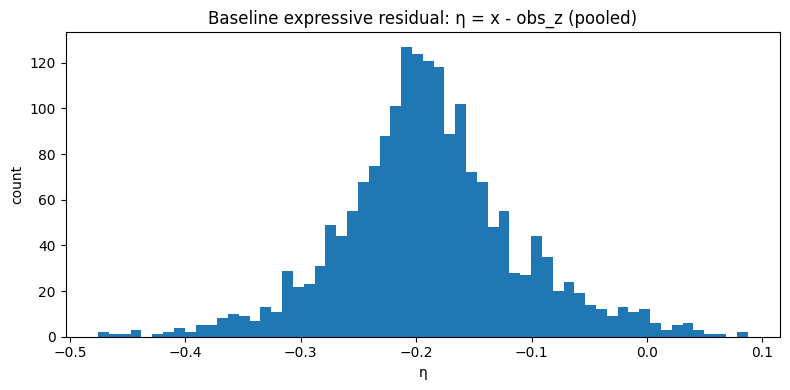

In [6]:
# Build pooled dataset across runs

dfs = [compute_event_features(rd) for rd in RUN_DIRS]
df_all = pd.concat(dfs, ignore_index=True)
df_all = df_all.sort_values(['run', 't', 'agent']).reset_index(drop=True)

print('Total rows:', len(df_all))
print('Finite obs_x rate:', float(np.isfinite(df_all['obs_x']).mean()))
display(df_all.head(10))

alpha_grid = PARAMS['alpha_grid']
df_all2 = add_pred_columns(df_all, alpha_grid)

eta0 = df_all2['eta_profile'].to_numpy()
print('Baseline eta = x - obs_z (pooled):', jarque_bera_stats(eta0))

plt.figure(figsize=(8, 4))
plt.hist(pd.Series(eta0).dropna(), bins=60)
plt.title('Baseline expressive residual: η = x - obs_z (pooled)')
plt.xlabel('η')
plt.ylabel('count')
plt.tight_layout()
plt.show()


## 2) Baseline: DeGroot-style prior (no current observation)



This baseline produces a prior prediction (no $x_i(t)$):

$$\hat z_i^{\text{prior}}(t)=\alpha\,z_{i,prev}(t)+(1-\alpha)\,\text{social}_i(t).$$



It’s mainly a reference point and a sanity check for alignment.


In [7]:
# Per-agent alpha selection (pooled over runs)

min_n = int(PARAMS['min_samples_per_agent'])
rows = []

for agent, dfa in df_all2.groupby('agent'):
    dfa = dfa[np.isfinite(dfa['obs_x'])].copy()
    if len(dfa) < min_n:
        continue

    best = best_alpha_for_group(dfa, alpha_grid)
    if not best:
        continue

    a = float(best['alpha'])
    base = jarque_bera_stats((dfa['obs_x'] - dfa['obs_z']).to_numpy())
    rmse = rmse_vs_obs_z(dfa, pred_col=f'pred_z_a{a}')

    rows.append({
        'agent': agent,
        'n': int(best['n']),
        'best_alpha': a,
        'best_p': float(best['p']),
        'best_jb': float(best['jb']),
        'best_skew': float(best['skew']),
        'best_kurt': float(best['kurt']),
        'baseline_p': float(base['p']) if np.isfinite(base['p']) else np.nan,
        'baseline_jb': float(base['jb']) if np.isfinite(base['jb']) else np.nan,
        'rmse_z_at_best_alpha': float(rmse),
    })

per_agent = pd.DataFrame(rows).sort_values(['best_jb', 'rmse_z_at_best_alpha']).reset_index(drop=True)

print('Agents evaluated:', len(per_agent))
display(per_agent.head(15))
print('Best-alpha summary:')
display(per_agent['best_alpha'].describe())


Agents evaluated: 30


,agent,n,best_alpha,best_p,best_jb,best_skew,best_kurt,baseline_p,baseline_jb,rmse_z_at_best_alpha
0,agent_25,59,0.45,0.999452,0.001096,-0.010154,2.994206,0.410893,1.778845,0.042536
1,agent_15,56,0.30,0.998523,0.002955,0.002109,2.964661,0.393840,1.863620,0.032624
2,agent_9,63,0.35,0.997709,0.004587,0.012548,3.033429,0.077637,5.111413,0.056792
3,agent_20,66,0.45,0.963384,0.074607,-0.012136,3.162913,0.259547,2.697638,0.027250
4,agent_23,56,0.35,0.958817,0.084110,0.036135,3.175568,0.793248,0.463240,0.035828
5,agent_7,67,0.15,0.941673,0.120194,-0.018674,2.795893,0.368515,1.996550,0.063938
6,agent_12,51,0.20,0.925935,0.153903,0.057773,2.756949,0.947573,0.107702,0.052202
7,agent_26,50,0.00,0.913679,0.180551,-0.131623,2.868218,0.930650,0.143743,0.042511
8,agent_27,80,0.15,0.900584,0.209424,0.002822,2.749410,0.016448,8.215053,0.047805
9,agent_21,65,0.20,0.899761,0.211252,-0.103424,2.812344,0.882079,0.250948,0.074426


Best-alpha summary:


count    30.000000
mean      0.341667
std       0.301171
min       0.000000
25%       0.025000
50%       0.350000
75%       0.537500
max       1.000000
Name: best_alpha, dtype: float64

In [8]:
# Leave-one-run-out validation: choose alpha on training runs, score on holdout

runs = sorted(df_all2['run'].unique())
min_n = int(PARAMS['min_samples_per_agent'])
records = []

for holdout in runs:
    train = df_all2[df_all2['run'] != holdout]
    test = df_all2[df_all2['run'] == holdout]

    agent_to_alpha = {}
    for agent, dfa in train.groupby('agent'):
        dfa = dfa[np.isfinite(dfa['obs_x'])].copy()
        if len(dfa) < min_n:
            continue
        best = best_alpha_for_group(dfa, alpha_grid)
        if best:
            agent_to_alpha[agent] = float(best['alpha'])

    for agent, dfa in test.groupby('agent'):
        if agent not in agent_to_alpha:
            continue
        dfa = dfa[np.isfinite(dfa['obs_x'])].copy()
        if len(dfa) < min_n:
            continue

        a = agent_to_alpha[agent]
        st = jarque_bera_stats(dfa[f'eta_a{a}'].to_numpy())
        base = jarque_bera_stats((dfa['obs_x'] - dfa['obs_z']).to_numpy())
        rmse = rmse_vs_obs_z(dfa, pred_col=f'pred_z_a{a}')

        records.append({
            'holdout_run': holdout,
            'agent': agent,
            'n': int(st['n']),
            'alpha_train_best': float(a),
            'p_holdout': float(st['p']),
            'jb_holdout': float(st['jb']),
            'baseline_p_holdout': float(base['p']) if np.isfinite(base['p']) else np.nan,
            'baseline_jb_holdout': float(base['jb']) if np.isfinite(base['jb']) else np.nan,
            'rmse_z_holdout': float(rmse),
        })

cv = pd.DataFrame(records)
print('LOO CV rows:', len(cv))
display(cv.head(10))

agg = cv.groupby('holdout_run', as_index=False).agg({
    'p_holdout': 'mean',
    'baseline_p_holdout': 'mean',
    'jb_holdout': 'mean',
    'baseline_jb_holdout': 'mean',
    'rmse_z_holdout': 'mean',
}).sort_values('holdout_run')

print('Per-run mean Gaussianity (higher p is better):')
display(agg)
print('Overall CV mean p:', float(cv['p_holdout'].mean()), 'baseline:', float(cv['baseline_p_holdout'].mean()))


LOO CV rows: 11


,holdout_run,agent,n,alpha_train_best,p_holdout,jb_holdout,baseline_p_holdout,baseline_jb_holdout,rmse_z_holdout
0,20260217-185316,agent_1,29,0.10,1.410991e-06,26.942436,6.768878e-11,46.832201,0.025009
1,20260217-185316,agent_2,28,0.65,8.931431e-04,14.041527,3.301254e-04,16.032076,0.033710
2,20260217-185316,agent_27,26,0.20,8.080591e-01,0.426240,2.428827e-06,25.856204,0.029994
3,20260217-185316,agent_29,25,0.00,4.999717e-01,1.386408,6.907128e-05,19.160743,0.073423
4,20260217-185316,agent_30,26,0.45,4.687933e-04,15.330697,1.118286e-09,41.222938,0.040755
5,20260217-185316,agent_8,28,0.75,3.253189e-09,39.087260,4.446994e-49,222.668882,0.017723
6,20260217-223650,agent_18,30,1.00,2.048641e-08,35.407008,6.282915e-03,10.139843,0.018693
7,20260217-223650,agent_23,25,0.45,9.638999e-01,0.073536,9.740178e-01,0.052651,0.031617
8,20260217-223650,agent_27,26,0.15,7.895599e-01,0.472559,7.718547e-01,0.517918,0.052165
9,20260217-223650,agent_30,27,0.50,2.629335e-01,2.671708,6.436464e-01,0.881212,0.050146


Per-run mean Gaussianity (higher p is better):


,holdout_run,p_holdout,baseline_p_holdout,jb_holdout,baseline_jb_holdout,rmse_z_holdout
0,20260217-185316,0.218232,0.000067,16.202428,61.962174,0.036769
1,20260217-223650,0.404946,0.479161,9.639715,7.588610,0.034374


Overall CV mean p: 0.30310234392464025 baseline: 0.2178368502347908


## 3) Expressive-noise model + ablation (features → “more Gaussian” noise)

We first focus on the **expression layer**: even if an agent’s latent belief $z$ is stable, the published stance $x$ can be systematically biased/noisy depending on context (topic similarity, strength, exposure, topology, …).

### Target we model
We define a proxy expression residual using the profile-based proxy latent `obs_z`:

$$\eta_i(t) := x_i(t) - \text{obs\_z}_i(t).$$

This $\eta$ is not the “true” error (because `obs_z` is only a proxy), but it gives a consistent supervised target across runs for learning expressive bias/variance patterns.

### Model class
We fit a **heteroscedastic Gaussian regression**:

$$\eta\mid\phi \sim \mathcal N(\mu_\eta(\phi),\,\sigma_\eta(\phi)^2),$$

where both $\mu_\eta$ and $\log\sigma_\eta^2$ are linear in the chosen feature vector $\phi$.

> Implementation detail: the fit is a practical 2-stage ridge approach:
- Fit $\mu_\eta(\phi)$ with ridge least squares on $\eta$
- Fit $\log\sigma_\eta(\phi)^2$ with ridge least squares on $\log(\text{resid}^2+\epsilon)$
- Apply a final multiplicative `sigma_scale` so standardized residuals have unit RMS on the training split

### What “make the noise Gaussian” means
After fitting $(\hat\mu,\hat\sigma)$ we look at standardized residuals:

$$r_t = \frac{\eta_t - \hat\mu_\eta(\phi_t)}{\hat\sigma_\eta(\phi_t)}.$$

If the model is well-calibrated, $r_t$ should be close to $\mathcal N(0,1)$: mean near 0, std near 1, and QQ/hist plots should look normal-ish.

### How we choose features (to avoid overfitting)
We evaluate candidate feature sets via **leave-one-run-out** (hold out entire runs). On the holdout, we compute:
- Gaussian fit: RMSE and Gaussian NLL of $\eta$
- Calibration: mean/std of $r$
- Shape diagnostic: Jarque–Bera (JB) on $r$ (diagnostic only)

Selection is primarily by **holdout Gaussian NLL** (portable predictive likelihood); JB is used as a secondary sanity check rather than a training loss.

In [9]:
# --- Expressive-noise modeling ablation (beyond x and z) ---
# Target: eta_profile = x - obs_z (proxy expressive noise)
# We model eta_profile ~ Normal(mu(features), sigma(features)^2)
# and evaluate on holdout runs:
# - predictive fit: RMSE of eta, Gaussian NLL of eta
# - shape diagnostics: standardized residual mean/std, JB/p

FEATURE_SETS = {
    'F0_const': [],
    'F1_pub': ['pub_topic_similarity', 'pub_strength'],
    'F2_pub+topo': ['pub_topic_similarity', 'pub_strength', 'topo_ts', 'topo_str'],
    'F3_full': [
        'pub_topic_similarity',
        'pub_strength',
        'topo_ts',
        'topo_str',
        'anchor_pro',
        'anchor_anti',
        'anchor_neutral',
        'n_used_pred',
        'n_used_total',
        'stance_weight',
    ],
}

min_n = int(PARAMS['min_samples_per_agent'])
runs = sorted(df_all['run'].unique())

def gaussian_nll(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
    y = np.asarray(y, dtype=float)
    mu = np.asarray(mu, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    m = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(m):
        return float('nan')
    y = y[m]
    mu = mu[m]
    v = sigma[m] ** 2
    return float(0.5 * np.mean(np.log(v) + ((y - mu) ** 2) / v))


records = []
for holdout in runs:
    train = df_all[df_all['run'] != holdout].copy()
    test = df_all[df_all['run'] == holdout].copy()

    for set_name, cols in FEATURE_SETS.items():
        ps = []
        jbs = []
        means = []
        stds = []
        rmses = []
        nlls = []
        n_agents = 0

        for agent, dtr in train.groupby('agent'):
            dtr = dtr[np.isfinite(dtr['eta_profile'])].copy()
            dte = test[test['agent'] == agent].copy()
            dte = dte[np.isfinite(dte['eta_profile'])].copy()

            if len(dtr) < min_n or len(dte) < 8:
                continue

            model = fit_noise_model(dtr, y_col='eta_profile', feature_cols=cols)
            mu, sigma = predict_noise(model, dte)

            y = dte['eta_profile'].to_numpy(dtype=float)
            e = standardized_residuals(y, mu, sigma)
            st = jarque_bera_stats(e)

            rmse = float(np.sqrt(np.mean((y - mu) ** 2)))
            nll = gaussian_nll(y, mu, sigma)

            if np.isfinite(st['p']):
                ps.append(float(st['p']))
            if np.isfinite(st['jb']):
                jbs.append(float(st['jb']))
            if e.size:
                means.append(float(np.mean(e)))
                stds.append(float(np.std(e)))
            if np.isfinite(rmse):
                rmses.append(rmse)
            if np.isfinite(nll):
                nlls.append(nll)
            n_agents += 1

        records.append(
            {
                'holdout_run': holdout,
                'feature_set': set_name,
                'n_agents': n_agents,
                'mean_p': float(np.mean(ps)) if ps else np.nan,
                'median_p': float(np.median(ps)) if ps else np.nan,
                'mean_jb': float(np.mean(jbs)) if jbs else np.nan,
                'mean_stdres_mean': float(np.mean(means)) if means else np.nan,
                'mean_stdres_std': float(np.mean(stds)) if stds else np.nan,
                'mean_rmse_eta': float(np.mean(rmses)) if rmses else np.nan,
                'mean_nll_eta': float(np.mean(nlls)) if nlls else np.nan,
            }
        )

abl = pd.DataFrame(records)

print('Ablation (LOO): standardized residual should look ~N(0,1)')
display(abl.sort_values(['feature_set', 'holdout_run']))

overall = (
    abl.groupby('feature_set', as_index=False)
    .agg(
        {
            'n_agents': 'sum',
            'mean_p': 'mean',
            'median_p': 'mean',
            'mean_jb': 'mean',
            'mean_stdres_mean': 'mean',
            'mean_stdres_std': 'mean',
            'mean_rmse_eta': 'mean',
            'mean_nll_eta': 'mean',
        }
    )
    .sort_values(['mean_nll_eta'], ascending=True)
    .reset_index(drop=True)
)

print('Ablation overall (averaged across holdouts):')
display(overall)

best_feature_set = str(overall.iloc[0]['feature_set'])
print('Best feature set (by mean_nll_eta):', best_feature_set)
print('Columns:', FEATURE_SETS[best_feature_set])


Ablation (LOO): standardized residual should look ~N(0,1)


,holdout_run,feature_set,n_agents,mean_p,median_p,mean_jb,mean_stdres_mean,mean_stdres_std,mean_rmse_eta,mean_nll_eta
0,20260216-211459,F0_const,9,0.471856,0.398699,1.745344,0.291141,0.994065,0.078682,-2.005289
4,20260216-225353,F0_const,15,0.713650,0.767936,0.755319,-0.864633,1.318405,0.110127,-1.298589
8,20260217-000531,F0_const,7,0.751853,0.827837,0.793175,0.549703,1.122003,0.094069,-1.713209
12,20260217-150345,F0_const,2,0.728442,0.728442,0.677219,0.285459,0.669805,0.048295,-2.448426
16,20260217-185316,F0_const,30,0.179471,0.036488,20.345877,0.167066,0.525953,0.049151,-2.286325
20,20260217-223650,F0_const,30,0.550863,0.674792,3.765552,-0.505829,0.850593,0.077426,-2.015041
1,20260216-211459,F1_pub,9,0.435682,0.280251,2.284444,-0.055311,1.042642,0.068500,-2.082390
5,20260216-225353,F1_pub,15,0.542158,0.533070,1.814590,-0.448508,1.110873,0.086184,-1.832907
9,20260217-000531,F1_pub,7,0.742759,0.719533,0.614903,0.825312,1.131938,0.089512,-1.588123
13,20260217-150345,F1_pub,2,0.749248,0.749248,0.578858,0.164088,0.690197,0.047414,-2.477963


Ablation overall (averaged across holdouts):


,feature_set,n_agents,mean_p,median_p,mean_jb,mean_stdres_mean,mean_stdres_std,mean_rmse_eta,mean_nll_eta
0,F1_pub,93,0.494332,0.413870,7.362983,-0.024506,0.931283,0.070662,-2.032147
1,F2_pub+topo,93,0.549401,0.591270,3.014563,-0.168996,1.051188,0.056247,-1.990821
2,F0_const,93,0.566022,0.572366,4.680414,-0.012849,0.913471,0.076292,-1.961147
3,F3_full,93,0.500166,0.538213,4.509286,-2.891535,8.491069,0.055914,1277.283145


Best feature set (by mean_nll_eta): F1_pub
Columns: ['pub_topic_similarity', 'pub_strength']


## 4) Latent belief filter (DeGroot prior + Gaussian correction)

Once we have a global way to predict expressive bias/variance, we can treat each published stance $x$ as a **noisy measurement** of latent belief $z$.

### Prior (DeGroot-style dynamics)
Before seeing the current message, we form a prior belief from (i) persistence and (ii) social exposure:

$$m_t = \alpha\,z_{t-1} + (1-\alpha)\,\text{social}_t,\qquad P_t \leftarrow P_{t-1} + q^2.$$

Here $q$ controls how much we expect latent belief to drift even if there’s no new evidence.

### Observation (expression-aware)
We use the noise model to predict $\mu_\eta(\phi_t)$ and $\sigma_\eta(\phi_t)$ and write:

$$x_t = z_t + \mu_\eta(\phi_t) + \varepsilon_t,\qquad \varepsilon_t\sim\mathcal N(0,\sigma_\eta(\phi_t)^2).$$

### Update (scalar Kalman-like)
Define the innovation and its variance:

$$y_t = x_t - \mu_\eta(\phi_t) - m_t,\qquad S_t = P_t + \sigma_\eta(\phi_t)^2.$$

Then the posterior mean update is:
$$\hat z_t = m_t + K_t\,y_t,\qquad K_t = \frac{P_t}{S_t}.$$

We track standardized innovations
$$e_t = \frac{y_t}{\sqrt{S_t}}$$
because a well-calibrated model should have $e_t\approx\mathcal N(0,1)$ on held-out runs.

Noise models fit for agents: 30
Per-agent (alpha,q) tuned: 30


,agent,n,nll,mean,std,skew,kurt,jb,p
0,agent_1,76,-2.337396,0.114577,0.879534,0.539720,3.057308,3.700164,1.572242e-01
1,agent_19,65,-2.305185,0.287442,0.552649,0.403431,2.574222,2.254179,3.239749e-01
2,agent_13,67,-2.245072,0.295447,0.581430,1.074711,4.724691,21.201514,2.489715e-05
3,agent_30,80,-2.219887,0.192321,0.621635,0.502289,3.932300,6.261203,4.369152e-02
4,agent_25,59,-2.212241,0.189123,0.669529,0.239711,3.622790,1.518544,4.680069e-01
5,agent_3,62,-2.198185,0.532980,0.712158,0.089827,3.216719,0.204710,9.027089e-01
6,agent_21,65,-2.194653,0.251822,0.603852,-0.276895,4.575797,7.555759,2.287114e-02
7,agent_22,63,-2.177752,0.233918,0.951814,0.443038,2.986423,2.061452,3.567479e-01
8,agent_11,65,-2.176506,0.239409,0.601743,0.097206,3.358852,0.451129,7.980655e-01
9,agent_6,60,-2.171888,0.293565,0.594932,-0.260594,4.681672,7.749146,2.076320e-02


Example agent: agent_1
alpha: 0.0 q: 0.005
Innovation diagnostics: {'n': 76, 'nll': -2.337396151104867, 'mean': 0.11457700382663549, 'std': 0.8795338838346245, 'skew': 0.539719550415757, 'kurt': 3.0573080459331554, 'jb': 3.7001644510199765, 'p': 0.15722423793896675}


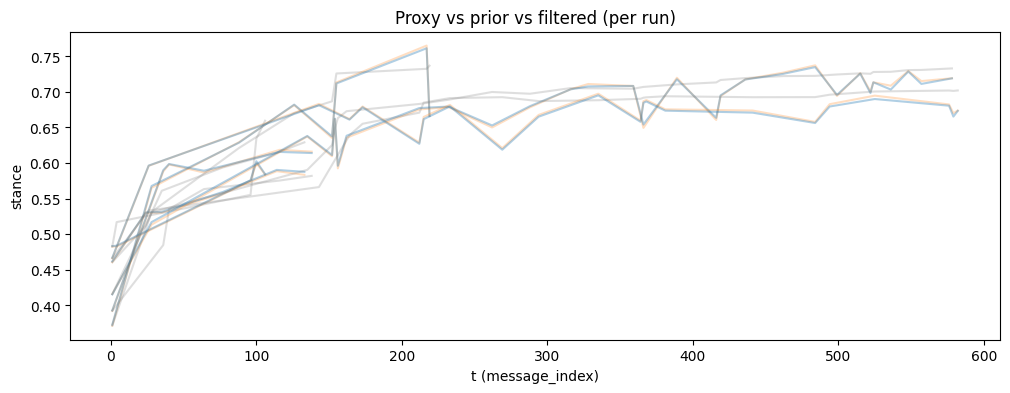

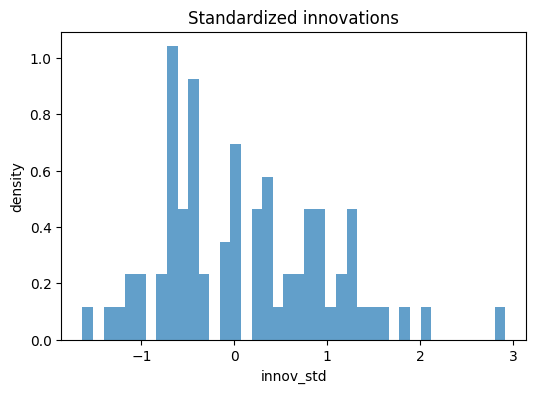

In [10]:
# --- Latent belief estimator: DeGroot prior + Gaussian correction (per agent) ---
# Model:
#   z_t = alpha * z_{t-1} + (1-alpha) * social_t + w_t,      w_t ~ N(0, q^2)
#   x_t = z_t + mu(features_t) + v_t,                        v_t ~ N(0, sigma(features_t)^2)
# Streaming update (scalar Kalman-like):
#   prior mean m_t, prior var P_t
#   innovation y_t = x_t - mu_t - m_t
#   S_t = P_t + sigma_t^2
#   K_t = P_t / S_t
#   zhat_t = m_t + K_t * y_t
#   P_t = (1-K_t) * P_t

from dataclasses import dataclass


@dataclass
class AgentFilterResult:
    df: pd.DataFrame
    diagnostics: dict


def _safe_array_like(n: int, fill=np.nan) -> np.ndarray:
    a = np.empty(n, dtype=float)
    a.fill(fill)
    return a


def estimate_latent_belief_for_agent(
    dfa: pd.DataFrame,
    alpha: float,
    noise_model,
    q: float,
) -> AgentFilterResult:
    dfa = dfa.sort_values(['run', 't']).copy()

    mu_eta, sigma_eta = predict_noise(noise_model, dfa)
    # Observation model: x = z + mu_eta + eps
    mu_obs = mu_eta
    R = np.maximum(1e-10, sigma_eta ** 2)

    zhat = _safe_array_like(len(dfa))
    zpred = _safe_array_like(len(dfa))
    innov = _safe_array_like(len(dfa))
    S_arr = _safe_array_like(len(dfa))
    innov_std = _safe_array_like(len(dfa))

    # Initialize belief from proxy at first point per run
    P = float(q ** 2)

    last_run = None
    for k, row in enumerate(dfa.itertuples(index=False)):
        if last_run != row.run:
            # reset at run boundary
            z_prev = float(row.obs_z)
            P = float(q ** 2)
            last_run = row.run

        social = float(row.social) if np.isfinite(row.social) else float(z_prev)
        m = float(alpha * z_prev + (1 - alpha) * social)
        P = float(P + q ** 2)

        y = float(row.obs_x - mu_obs[k] - m)
        S = float(P + R[k])
        K = float(P / S) if S > 0 else 0.0

        z_new = float(m + K * y)
        P = float((1 - K) * P)

        zhat[k] = z_new
        zpred[k] = m
        innov[k] = y
        S_arr[k] = S
        innov_std[k] = y / np.sqrt(S) if S > 0 else np.nan

        z_prev = z_new

    out = dfa.copy()
    out['mu_eta_hat'] = mu_eta
    out['sigma_eta_hat'] = sigma_eta
    out['z_pred'] = zpred
    out['z_hat'] = zhat
    out['innov'] = innov
    out['innov_var'] = S_arr
    out['innov_std'] = innov_std

    y = out['innov'].to_numpy(dtype=float)
    S = out['innov_var'].to_numpy(dtype=float)
    m = np.isfinite(y) & np.isfinite(S) & (S > 0)
    y = y[m]
    S = S[m]

    e = y / np.sqrt(S)
    st = jarque_bera_stats(e)

    # Gaussian negative log-likelihood of innovations
    nll = float(0.5 * np.mean(np.log(S) + (y * y) / S)) if y.size else np.nan

    diag = {
        'n': int(y.size),
        'nll': nll,
        'mean': float(np.mean(e)) if e.size else np.nan,
        'std': float(np.std(e)) if e.size else np.nan,
        'skew': st.get('skew', np.nan),
        'kurt': st.get('kurt', np.nan),
        'jb': st.get('jb', np.nan),
        'p': st.get('p', np.nan),
    }

    return AgentFilterResult(df=out, diagnostics=diag)


def pick_alpha_q_for_agent(
    dfa: pd.DataFrame,
    noise_model,
    alpha_grid,
    q_grid,
) -> tuple[float, float, dict]:
    best = None
    best_alpha = None
    best_q = None
    best_diag = None

    for alpha in alpha_grid:
        for q in q_grid:
            res = estimate_latent_belief_for_agent(dfa, alpha=alpha, noise_model=noise_model, q=q)
            diag = res.diagnostics
            if diag['n'] < 20 or not np.isfinite(diag.get('nll', np.nan)):
                continue

            # Primary objective: innovation Gaussian log-likelihood (calibrates variance)
            # Tie-breaker: higher JB p-value
            score = (float(diag['nll']), -float(diag.get('p', np.nan)) if np.isfinite(diag.get('p', np.nan)) else 0.0)
            if best is None or score < best:
                best = score
                best_alpha = alpha
                best_q = q
                best_diag = diag

    if best_alpha is None:
        best_alpha = float(alpha_grid[len(alpha_grid) // 2])
        best_q = float(q_grid[len(q_grid) // 2])
        best_diag = {'p': np.nan, 'jb': np.nan, 'mean': np.nan, 'std': np.nan, 'nll': np.nan, 'n': 0}

    return float(best_alpha), float(best_q), best_diag


# Fit one noise model per agent using the chosen feature set, then tune (alpha, q)
cols = FEATURE_SETS.get(best_feature_set, [])
alpha_grid = np.linspace(0.0, 0.95, 20)
q_grid = np.array([0.005, 0.01, 0.02, 0.05, 0.1])

noise_models = {}
for agent, dfa in df_all.groupby('agent'):
    dfa = dfa[np.isfinite(dfa['eta_profile'])].copy()
    if len(dfa) < PARAMS['min_samples_per_agent']:
        continue
    noise_models[agent] = fit_noise_model(dfa, y_col='eta_profile', feature_cols=cols)

print('Noise models fit for agents:', len(noise_models))

agent_params = {}
agent_diags = {}
agent_estimates = {}
for agent, dfa in df_all.groupby('agent'):
    if agent not in noise_models:
        continue
    alpha, q, diag = pick_alpha_q_for_agent(dfa, noise_models[agent], alpha_grid, q_grid)
    agent_params[agent] = {'alpha': alpha, 'q': q}
    agent_diags[agent] = diag
    agent_estimates[agent] = estimate_latent_belief_for_agent(dfa, alpha=alpha, noise_model=noise_models[agent], q=q)

print('Per-agent (alpha,q) tuned:', len(agent_params))

# Show diagnostics summary
if agent_diags:
    dd = pd.DataFrame([
        {'agent': a, **d} for a, d in agent_diags.items()
    ]).sort_values(['nll']).reset_index(drop=True)
    display(dd)

# Plot one example agent (per run)
example_agent = sorted(agent_estimates.keys())[0] if agent_estimates else None
if example_agent is not None:
    est = agent_estimates[example_agent].df
    diag = agent_estimates[example_agent].diagnostics
    print('Example agent:', example_agent)
    print('alpha:', agent_params[example_agent]['alpha'], 'q:', agent_params[example_agent]['q'])
    print('Innovation diagnostics:', diag)

    plt.figure(figsize=(12, 4))
    for run, d in est.groupby('run'):
        d = d.sort_values('t')
        plt.plot(d['t'], d['obs_z'], color='tab:gray', alpha=0.25)
        plt.plot(d['t'], d['z_pred'], color='tab:orange', alpha=0.25)
        plt.plot(d['t'], d['z_hat'], color='tab:blue', alpha=0.35)
    plt.title('Proxy vs prior vs filtered (per run)')
    plt.xlabel('t (message_index)')
    plt.ylabel('stance')
    plt.show()

    e = est['innov_std'].to_numpy(dtype=float)
    e = e[np.isfinite(e)]
    plt.figure(figsize=(6, 4))
    plt.hist(e, bins=40, density=True, alpha=0.7)
    plt.title('Standardized innovations')
    plt.xlabel('innov_std')
    plt.ylabel('density')
    plt.show()


## 5) Portable global noise-debias model (run/agent-agnostic)

Each run can contain completely different agents, so anything per-agent won’t transfer. For downstream opinion-dynamics notebooks, we want a **fixed, portable preprocessing step** that turns an expressed stance $x$ into an innate-belief estimate $z$.

We fit ONE shared expressive-noise model on pooled data:
$$\eta\mid\phi \sim \mathcal N(\mu_\eta(\phi),\sigma_\eta(\phi)^2),\qquad \eta := x - z_{\text{proxy}}.$$
Then we define the debiased innate belief estimate:
$$z_{\text{innate\_debiased}} := x - \hat\mu_\eta(\phi).$$

This notebook stops here (no DeGroot/FJ smoothing). Any smoothing/dynamics should be applied **downstream** in the DeGroot/FJ latent-belief notebooks using $z_{\text{innate\_debiased}}$ as the observation input.

In [11]:
# --- Final: GLOBAL expressive-noise model (portable across runs/agents) ---
# This notebook’s output is a SINGLE "innate belief" estimate per self-expression event:
#
#   z_innate_debiased(t) = x(t) - mu_eta_hat(phi_t)
#
# where the global noise model is:
#   eta_profile = x - z_proxy  ~  Normal(mu(phi), sigma(phi)^2)
#
# We intentionally do NOT do any temporal/social smoothing here.
# DeGroot/FJ (or other dynamics) should be applied downstream in the latent-belief notebooks.

from dataclasses import dataclass


@dataclass
class NoiseModel:
    feature_set_name: str
    feature_cols: list[str]
    global_noise_model: dict
    l2: float


def fit_global_noise_model(
    df_all_events: pd.DataFrame,
    feature_set_name: str,
    *,
    l2_grid: np.ndarray | list[float] | None = None,
    run_col: str = 'run',
) -> NoiseModel:
    feature_cols = FEATURE_SETS[feature_set_name]

    d = df_all_events.copy()
    if 'eta_profile' not in d.columns:
        d['eta_profile'] = d['obs_x'].to_numpy(dtype=float) - d['obs_z'].to_numpy(dtype=float)

    d = d[np.isfinite(d['eta_profile'])].copy()

    # Pick ridge strength by leave-one-run-out validation (runs are our natural folds).
    best_l2, cv_scores = cv_pick_l2_noise_model(
        d,
        y_col='eta_profile',
        feature_cols=feature_cols,
        run_col=run_col,
        l2_grid=l2_grid,
    )
    print('Chosen global ridge l2:', best_l2)
    if isinstance(cv_scores, pd.DataFrame) and not cv_scores.empty:
        display(cv_scores[cv_scores['_kind'] == 'agg'].sort_values('nll').head(10))

    global_noise_model = fit_noise_model(d, y_col='eta_profile', feature_cols=feature_cols, l2=best_l2)

    return NoiseModel(
        feature_set_name=str(feature_set_name),
        feature_cols=list(feature_cols),
        global_noise_model=global_noise_model,
        l2=float(best_l2),
    )


def apply_global_noise_model(df_all_events: pd.DataFrame, model: NoiseModel) -> pd.DataFrame:
    d = df_all_events.copy()

    if 'eta_profile' not in d.columns:
        d['eta_profile'] = d['obs_x'].to_numpy(dtype=float) - d['obs_z'].to_numpy(dtype=float)

    mu_eta_hat, sigma_eta_hat = predict_noise(model.global_noise_model, d[model.feature_cols])
    mu_eta_hat = np.asarray(mu_eta_hat, dtype=float)
    sigma_eta_hat = np.asarray(sigma_eta_hat, dtype=float)
    sigma_eta_hat = np.maximum(sigma_eta_hat, 1e-8)

    d['mu_eta_hat'] = mu_eta_hat
    d['sigma_eta_hat'] = sigma_eta_hat
    d['z_innate_debiased'] = d['obs_x'].to_numpy(dtype=float) - d['mu_eta_hat'].to_numpy(dtype=float)

    return d


# Fit the final global noise model using the selected feature set
final_model_global = fit_global_noise_model(
    df_all,
    feature_set_name=best_feature_set,
    l2_grid=np.array([0.0, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2], dtype=float),
)
print('Global noise feature set:', final_model_global.feature_set_name)
print('Global noise feature cols:', final_model_global.feature_cols)
print('Global noise ridge l2:', final_model_global.l2)

final_out_global = apply_global_noise_model(df_all, final_model_global)
print('Global output rows:', len(final_out_global))

# Quick sanity: distribution of debiased stance
z = final_out_global['z_innate_debiased'].to_numpy(dtype=float)
z = z[np.isfinite(z)]
print('z_innate_debiased mean/std:', float(np.mean(z)), float(np.std(z)))

Chosen global ridge l2: 0.01


,holdout,l2,n_val,nll,_kind
48,__AGG__,1.000000e-02,1888.0,-2.068649,agg
49,__AGG__,1.000000e-03,1888.0,-2.068591,agg
50,__AGG__,1.000000e-04,1888.0,-2.068586,agg
51,__AGG__,1.000000e-05,1888.0,-2.068585,agg
52,__AGG__,1.000000e-06,1888.0,-2.068585,agg
53,__AGG__,1.000000e-07,1888.0,-2.068585,agg
54,__AGG__,1.000000e-08,1888.0,-2.068585,agg
55,__AGG__,0.000000e+00,1888.0,-2.068585,agg


Global noise feature set: F1_pub
Global noise feature cols: ['pub_topic_similarity', 'pub_strength']
Global noise ridge l2: 0.01
Global output rows: 1888
z_innate_debiased mean/std: 0.6822657710844443 0.05479370838623252


In [12]:
# --- Export: write global innate belief per run (for reuse in other notebooks) ---
# Output location: modeling/cleaned_data/run_*/latent_belief_global.jsonl
#
# Each row corresponds to a self-expression event (agent publishes a message).
#
# This notebook exports ONE innate-belief estimate:
#   z_innate_debiased = obs_x - mu_eta_hat
#
# Downstream (DeGroot/FJ) notebooks can apply smoothing/dynamics using this as obs_z.

import json


def export_global_innate_belief(df_out: pd.DataFrame, clean_dir: Path, model: NoiseModel) -> list[Path]:
    if df_out is None or len(df_out) == 0:
        print('No rows to export.')
        return []

    required = ['run', 't', 'agent', 'obs_x', 'obs_z', 'mu_eta_hat', 'sigma_eta_hat', 'social', 'z_innate_debiased']
    missing = [c for c in required if c not in df_out.columns]
    if missing:
        raise KeyError(f'final_out_global missing columns needed for export: {missing}')

    written: list[Path] = []

    for run, d in df_out.groupby('run'):
        run_dir = clean_dir / f'run_{run}'
        run_dir.mkdir(parents=True, exist_ok=True)
        out_fp = run_dir / 'latent_belief_global.jsonl'

        d = d.sort_values(['t', 'agent']).copy()

        meta = {
            'kind': 'global_expressive_noise_debias',
            'feature_set': str(model.feature_set_name),
            'feature_cols': list(model.feature_cols),
            'ridge_l2': float(model.l2),
            'z_field': 'z_innate_debiased',
        }

        with out_fp.open('w', encoding='utf-8') as f:
            f.write(json.dumps({'_meta': meta}, ensure_ascii=False) + '\n')

            for row in d.itertuples(index=False):
                rec = {
                    'run': str(run),
                    't': int(getattr(row, 't')),
                    'agent': str(getattr(row, 'agent')),
                    # raw observations
                    'obs_x': float(getattr(row, 'obs_x')) if np.isfinite(getattr(row, 'obs_x')) else None,
                    'obs_z_proxy': float(getattr(row, 'obs_z')) if np.isfinite(getattr(row, 'obs_z')) else None,
                    # social term used downstream (computed deterministically from logs)
                    'social': float(getattr(row, 'social')) if np.isfinite(getattr(row, 'social')) else None,
                    # expressive-noise model outputs
                    'mu_eta_hat': float(getattr(row, 'mu_eta_hat')) if np.isfinite(getattr(row, 'mu_eta_hat')) else None,
                    'sigma_eta_hat': float(getattr(row, 'sigma_eta_hat')) if np.isfinite(getattr(row, 'sigma_eta_hat')) else None,
                    # debiased innate belief
                    'z_innate_debiased': float(getattr(row, 'z_innate_debiased'))
                    if np.isfinite(getattr(row, 'z_innate_debiased'))
                    else None,
                    # optional context if present
                    'n_used_pred': int(getattr(row, 'n_used_pred')) if hasattr(row, 'n_used_pred') else None,
                    'n_used_total': int(getattr(row, 'n_used_total')) if hasattr(row, 'n_used_total') else None,
                }
                f.write(json.dumps(rec, ensure_ascii=False) + '\n')

        written.append(out_fp)

    return written


written = export_global_innate_belief(final_out_global, CLEAN, final_model_global)
print('Exported innate belief files:')
for p in written:
    print(' ', p)
print('Tip: DeGroot/FJ baseline notebooks can now load z_innate_debiased as obs_z.')

Exported innate belief files:
  /home/sammli/llm-network/modeling/cleaned_data/run_20260216-211459/latent_belief_global.jsonl
  /home/sammli/llm-network/modeling/cleaned_data/run_20260216-225353/latent_belief_global.jsonl
  /home/sammli/llm-network/modeling/cleaned_data/run_20260217-000531/latent_belief_global.jsonl
  /home/sammli/llm-network/modeling/cleaned_data/run_20260217-150345/latent_belief_global.jsonl
  /home/sammli/llm-network/modeling/cleaned_data/run_20260217-185316/latent_belief_global.jsonl
  /home/sammli/llm-network/modeling/cleaned_data/run_20260217-223650/latent_belief_global.jsonl
Tip: DeGroot/FJ baseline notebooks can now load z_innate_debiased as obs_z.


## 6) Global noise-model diagnostics (sanity check)

After fitting the global noise model, we can directly inspect whether the standardized residuals
$$r = \frac{\eta-\hat\mu_\eta(\phi)}{\hat\sigma_\eta(\phi)}$$
look approximately standard normal (histogram + QQ) and whether predicted $\hat\sigma$ is calibrated (binned plot of predicted sigma vs empirical residual std).

Note: the plots below are **in-sample** (fit and evaluated on the same pooled data). For a stricter generalization check, compute the same diagnostics on held-out runs (LOO), using noise models fit on the other runs only.

GLOBAL noise-model diagnostics on ALL data:
  n=1888
  RMSE(resid)=0.0706
  mean NLL=-1.2336
  standardized resid mean=-0.0001, std=1.0000
  JB=105.205, p=1.43e-23


,n,r_mean,r_std,resid_rmse,sigma_mean
run,,,,,
20260217-223650,597,-0.437994,0.853811,0.067266,0.070247
20260217-185316,595,0.075087,0.752503,0.053036,0.070206
20260216-225353,225,-0.195128,1.145982,0.083981,0.072476
20260216-211459,181,0.256628,1.010016,0.072451,0.069670
20260217-000531,180,0.827924,1.106447,0.097241,0.070577
20260217-150345,110,0.591370,1.049274,0.084655,0.070694


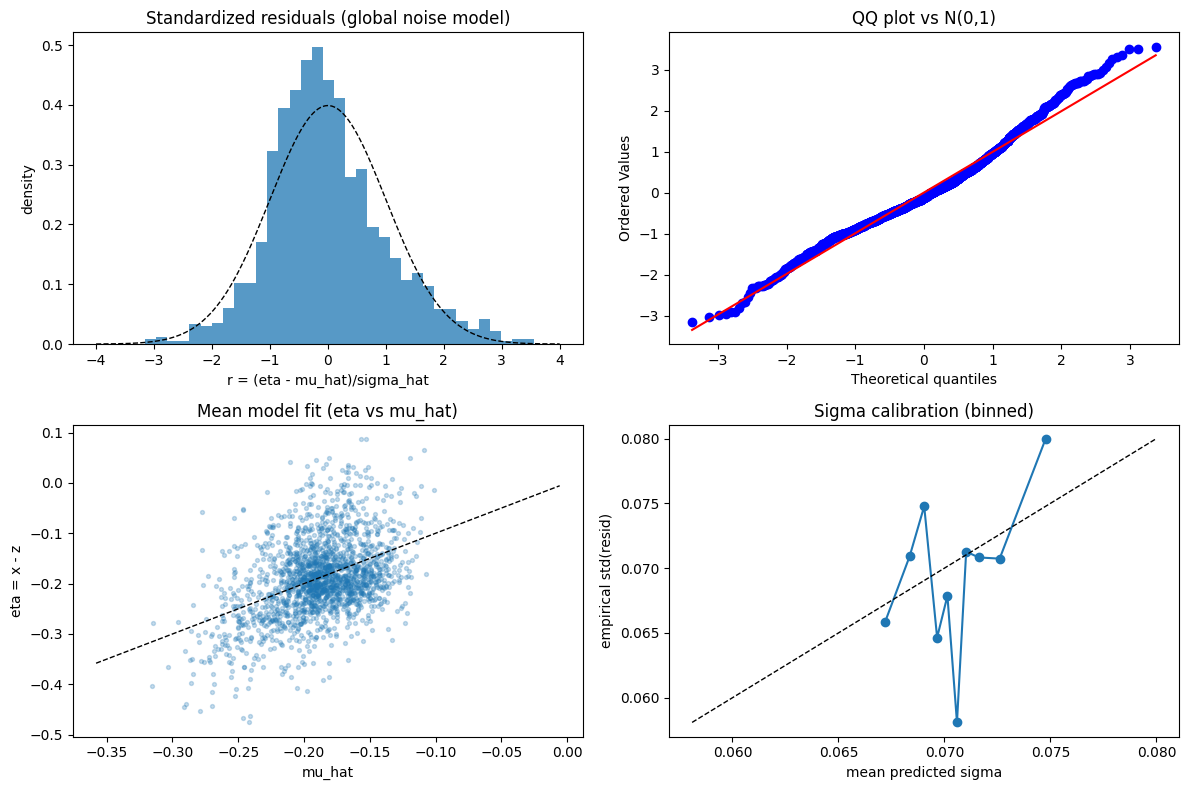

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# --- Global noise-model evaluation on ALL global data ---

def _pick_col(df: pd.DataFrame, candidates: list[str]) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns exist: {candidates}")

# Prefer the post-processed global events table if present
_df = df_all2 if "df_all2" in globals() and isinstance(df_all2, pd.DataFrame) else df_all

x_col = _pick_col(_df, ["obs_x", "x", "published_stance", "stance", "stance_score"])
z_col = _pick_col(_df, ["obs_z", "z", "proxy", "proxy_z"])
run_col = "run" if "run" in _df.columns else ("run_id" if "run_id" in _df.columns else None)

# Figure out which feature columns were used by the global noise model
_noise_features = (
    getattr(final_model_global, "global_noise_features", None)
    or getattr(final_model_global, "noise_features", None)
    or getattr(final_model_global, "feature_cols", None)
    or globals().get("noise_features")
)
if _noise_features is None:
    raise RuntimeError("Could not find global noise feature list (expected on final_model_global or as noise_features)")

noise_model = getattr(final_model_global, "global_noise_model", None)
if noise_model is None:
    raise RuntimeError("final_model_global.global_noise_model is missing")

eta = (_df[x_col].to_numpy(dtype=float) - _df[z_col].to_numpy(dtype=float))

# NOTE: In this notebook, predict_noise expects a DataFrame (not a matrix)
pred = predict_noise(noise_model, _df[_noise_features])
if isinstance(pred, tuple) and len(pred) == 2:
    mu_hat, sigma_hat = pred
elif isinstance(pred, dict):
    mu_hat = pred.get("mu")
    sigma_hat = pred.get("sigma")
else:
    raise TypeError(f"Unexpected predict_noise output type: {type(pred)}")

mu_hat = np.asarray(mu_hat, dtype=float)
sigma_hat = np.asarray(sigma_hat, dtype=float)

# Guard against tiny/invalid sigmas
sigma_hat = np.maximum(sigma_hat, 1e-8)

resid = eta - mu_hat
r = resid / sigma_hat

rmse = float(np.sqrt(np.mean(resid**2)))
nll = float(0.5 * np.mean(np.log(2 * np.pi * sigma_hat**2) + (resid**2) / (sigma_hat**2)))
jb_stat, jb_p = stats.jarque_bera(r)
print(
    "GLOBAL noise-model diagnostics on ALL data:\n"
    f"  n={len(r)}\n"
    f"  RMSE(resid)={rmse:.4f}\n"
    f"  mean NLL={nll:.4f}\n"
    f"  standardized resid mean={np.mean(r):.4f}, std={np.std(r):.4f}\n"
    f"  JB={jb_stat:.3f}, p={jb_p:.3g}"
)

# Per-run summary (optional if run column exists)
if run_col is not None:
    per = (
        pd.DataFrame({"run": _df[run_col].values, "r": r, "resid": resid, "sigma": sigma_hat})
        .groupby("run")
        .agg(
            n=("r", "size"),
            r_mean=("r", "mean"),
            r_std=("r", "std"),
            resid_rmse=("resid", lambda x: float(np.sqrt(np.mean(np.asarray(x) ** 2)))),
            sigma_mean=("sigma", "mean"),
        )
        .sort_values("n", ascending=False)
    )
    display(per)

# Plots: histogram + QQ + mean-fit scatter + variance calibration by sigma bins
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1) Histogram of standardized residuals with N(0,1) overlay
ax = axes[0, 0]
ax.hist(r, bins=35, density=True, alpha=0.75)
xgrid = np.linspace(-4, 4, 400)
ax.plot(xgrid, stats.norm.pdf(xgrid, 0, 1), "k--", linewidth=1)
ax.set_title("Standardized residuals (global noise model)")
ax.set_xlabel("r = (eta - mu_hat)/sigma_hat")
ax.set_ylabel("density")

# 2) QQ plot vs Normal
ax = axes[0, 1]
stats.probplot(r, dist="norm", plot=ax)
ax.set_title("QQ plot vs N(0,1)")

# 3) Predicted mean vs observed eta scatter
ax = axes[1, 0]
# downsample for speed/clarity
if len(mu_hat) > 5000:
    idx = np.random.default_rng(0).choice(len(mu_hat), size=5000, replace=False)
else:
    idx = slice(None)
ax.scatter(mu_hat[idx], eta[idx], s=8, alpha=0.25)
lo = float(np.quantile(np.concatenate([mu_hat[idx], eta[idx]]), 0.01))
hi = float(np.quantile(np.concatenate([mu_hat[idx], eta[idx]]), 0.99))
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1)
ax.set_title("Mean model fit (eta vs mu_hat)")
ax.set_xlabel("mu_hat")
ax.set_ylabel("eta = x - z")

# 4) Variance calibration: bin by predicted sigma
ax = axes[1, 1]
q_edges = np.quantile(sigma_hat, np.linspace(0, 1, 11))
# ensure strictly increasing edges
q_edges = np.unique(q_edges)
if len(q_edges) >= 4:
    bin_id = np.digitize(sigma_hat, q_edges[1:-1], right=True)
    rows = []
    for b in range(int(bin_id.min()), int(bin_id.max()) + 1):
        m = bin_id == b
        if int(m.sum()) < 10:
            continue
        rows.append(
            {
                "sigma_pred": float(np.mean(sigma_hat[m])),
                "resid_std": float(np.std(resid[m])),
                "n": int(m.sum()),
            }
        )
    cal = pd.DataFrame(rows).sort_values("sigma_pred")
    ax.plot(cal["sigma_pred"], cal["resid_std"], "o-")
    lo2 = float(min(cal["sigma_pred"].min(), cal["resid_std"].min()))
    hi2 = float(max(cal["sigma_pred"].max(), cal["resid_std"].max()))
    ax.plot([lo2, hi2], [lo2, hi2], "k--", linewidth=1)
    ax.set_title("Sigma calibration (binned)")
    ax.set_xlabel("mean predicted sigma")
    ax.set_ylabel("empirical std(resid)")
else:
    ax.text(0.5, 0.5, "Not enough sigma variation for bin-calibration plot", ha="center", va="center")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

## Summary (what to use going forward)


### The final portable estimator (GLOBAL)

Use the global model produced in the final code cell:

- `final_model_global` (shared noise model + shared $(\alpha,q)$)

- `final_out_global` (per-event latent belief series)



It implements:



1) **Expressive noise model** (shared across agents):

$$\eta(t)=x(t)-\text{obs\_z}(t),\quad \eta\mid\phi\sim\mathcal N(\mu_\eta(\phi),\sigma_\eta(\phi)^2).$$



2) **Dynamics prior** (shared):

$$z(t)=\alpha z(t-1)+(1-\alpha)\,\text{social}(t)+w(t),\quad w(t)\sim\mathcal N(0,q^2).$$



3) **Standardized innovation** (what we check for Gaussianity):

$$e_t=\frac{x_t-\mu_\eta(\phi_t)-m_t}{\sqrt{P_t+\sigma_\eta(\phi_t)^2}}$$

where $m_t$ and $P_t$ are the prior mean/variance from the dynamics step.
